In [1]:
import os
import datetime

import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

mpl.rcParams['figure.figsize'] = (8, 6)
mpl.rcParams['axes.grid'] = False
path = r'Datasets\DEVRT\NISSAN LEAF\20230421_NISSAN_DONOSTIA_ULIA_056.csv'
df = pd.read_csv(path)
df.fillna(0, inplace=True)
df.head()


pwr = (df['Motor Pwr(w)'].values)
spd = (df['speed'].values)
rpm = (df['rpm'].values)
trq = (df['Torque Nm'].values)
df = pd.DataFrame({'speed': spd, 'rpm': rpm, 'torque': trq, 'power': pwr,})


In [2]:
column_indices = {name: i for i, name in enumerate(df.columns)}

n = len(df)
train_df = df[0:int(n*0.7)]
val_df = df[int(n*0.7):int(n*0.9)]
test_df = df[int(n*0.9):]

num_features = df.shape[1]

In [3]:
train_mean = train_df.mean()
train_std = train_df.std()

train_df = (train_df - train_mean) / train_std
val_df = (val_df - train_mean) / train_std
test_df = (test_df - train_mean) / train_std

C:\Users\Claudio\AppData\Local\Temp\ipykernel_31964\3214313372.py:5: UserWarning: FixedFormatter should only be used together with FixedLocator
  _ = ax.set_xticklabels(df.keys(), rotation=90)


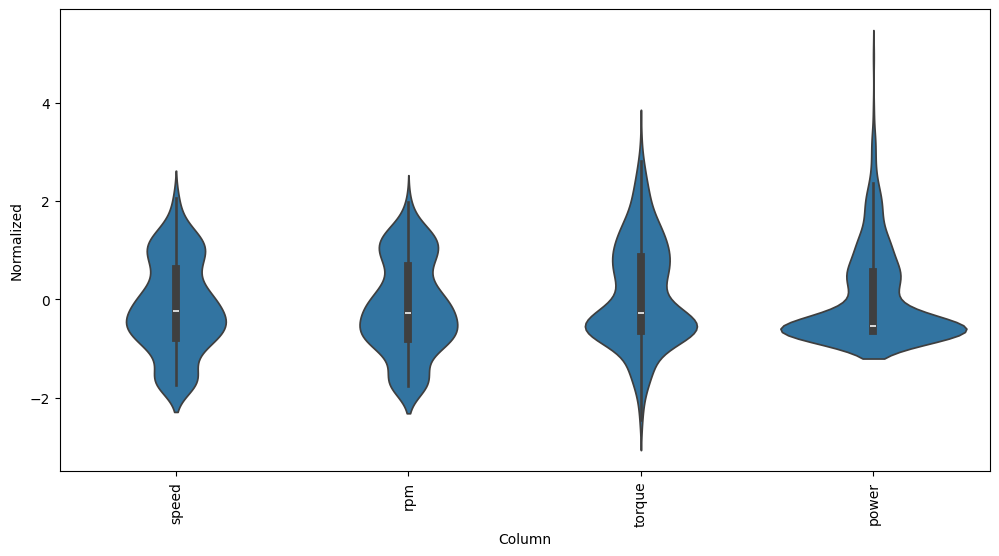

In [4]:
df_std = (df - train_mean) / train_std
df_std = df_std.melt(var_name='Column', value_name='Normalized')
plt.figure(figsize=(12, 6))
ax = sns.violinplot(x='Column', y='Normalized', data=df_std)
_ = ax.set_xticklabels(df.keys(), rotation=90)

In [5]:
class WindowGenerator():
  def __init__(self, input_width, label_width, shift,
               train_df=train_df, val_df=val_df, test_df=test_df,
               label_columns=None):
    # Store the raw data.
    self.train_df = train_df
    self.val_df = val_df
    self.test_df = test_df

    # Work out the label column indices.
    self.label_columns = label_columns
    if label_columns is not None:
      self.label_columns_indices = {name: i for i, name in
                                    enumerate(label_columns)}
    self.column_indices = {name: i for i, name in
                           enumerate(train_df.columns)}

    # Work out the window parameters.
    self.input_width = input_width
    self.label_width = label_width
    self.shift = shift

    self.total_window_size = input_width + shift

    self.input_slice = slice(0, input_width)
    self.input_indices = np.arange(self.total_window_size)[self.input_slice]

    self.label_start = self.total_window_size - self.label_width
    self.labels_slice = slice(self.label_start, None)
    self.label_indices = np.arange(self.total_window_size)[self.labels_slice]

  def __repr__(self):
    return '\n'.join([
        f'Total window size: {self.total_window_size}',
        f'Input indices: {self.input_indices}',
        f'Label indices: {self.label_indices}',
        f'Label column name(s): {self.label_columns}'])

In [6]:
def split_window(self, features):
  inputs = features[:, self.input_slice, :]
  labels = features[:, self.labels_slice, :]
  if self.label_columns is not None:
    labels = tf.stack(
        [labels[:, :, self.column_indices[name]] for name in self.label_columns],
        axis=-1)

  # Slicing doesn't preserve static shape information, so set the shapes
  # manually. This way the `tf.data.Datasets` are easier to inspect.
  inputs.set_shape([None, self.input_width, None])
  labels.set_shape([None, self.label_width, None])

  return inputs, labels

WindowGenerator.split_window = split_window

In [7]:
def plot(self, model=None, plot_col='T (degC)', max_subplots=3):
  inputs, labels = self.example
  plt.figure(figsize=(12, 8))
  plot_col_index = self.column_indices[plot_col]
  max_n = min(max_subplots, len(inputs))
  for n in range(max_n):
    plt.subplot(max_n, 1, n+1)
    plt.ylabel(f'{plot_col} [normed]')
    plt.plot(self.input_indices, inputs[n, :, plot_col_index],
             label='Inputs', marker='.', zorder=-10)

    if self.label_columns:
      label_col_index = self.label_columns_indices.get(plot_col, None)
    else:
      label_col_index = plot_col_index

    if label_col_index is None:
      continue

    plt.scatter(self.label_indices, labels[n, :, label_col_index],
                edgecolors='k', label='Labels', c='#2ca02c', s=64)
    if model is not None:
      predictions = model(inputs)
      plt.scatter(self.label_indices, predictions[n, :, label_col_index],
                  marker='X', edgecolors='k', label='Predictions',
                  c='#ff7f0e', s=64)

    if n == 0:
      plt.legend()

  plt.xlabel('Time [h]')

WindowGenerator.plot = plot

In [8]:
w2 = WindowGenerator(input_width=6, label_width=1, shift=1,
                     label_columns=['power'])
w2

Total window size: 7
Input indices: [0 1 2 3 4 5]
Label indices: [6]
Label column name(s): ['power']

In [9]:
# Stack three slices, the length of the total window.
example_window = tf.stack([np.array(train_df[:w2.total_window_size]),
                           np.array(train_df[100:100+w2.total_window_size]),
                           np.array(train_df[200:200+w2.total_window_size])])

example_inputs, example_labels = w2.split_window(example_window)

print('All shapes are: (batch, time, features)')
print(f'Window shape: {example_window.shape}')
print(f'Inputs shape: {example_inputs.shape}')
print(f'Labels shape: {example_labels.shape}')

All shapes are: (batch, time, features)
Window shape: (3, 7, 4)
Inputs shape: (3, 6, 4)
Labels shape: (3, 1, 1)


In [10]:
OUT_STEPS = 24
multi_window = WindowGenerator(input_width=24,
                               label_width=OUT_STEPS,
                               shift=OUT_STEPS)

multi_window.plot()
multi_window

AttributeError: 'WindowGenerator' object has no attribute 'example'

In [11]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler

# 1. Configuração do dispositivo (RTX 4060)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Rodando no dispositivo: {device}")

# --- 2. Preparação dos Dados (Protegido contra múltiplas execuções) ---

# GERA UMA CÓPIA EXPANDIDA APENAS SE df2 NÃO EXISTIR OU SE df FOR O ORIGINAL
if 'df' not in locals() or len(df) == len(df):
    # Faz o concat a partir do df original de poucas linhas
    df = pd.concat([df] * 50, ignore_index=True)
    # Adiciona o ruído diretamente usando o tamanho correto do df2
    df['power'] += np.random.normal(0, 50, size=len(df))
    print(f"Dataset expandido com sucesso! Total de linhas: {len(df)}")
else:
    print(f"df2 já estava na memória com {len(df)} linhas. Avançando para evitar sobrecarga.")

# A partir daqui, o script passa a consumir estritamente o df2 fixo
X_raw = df[['speed', 'rpm', 'torque']].values
y_raw = df['power'].values.reshape(-1, 1)

# O restante do código de escalonamento e treino segue idêntico...

# --- 3. Arquitetura com RNN Simples (Modificada) ---
class PowerPredictorSimpleRNN(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=64, num_layers=2, output_dim=4):
        super(PowerPredictorSimpleRNN, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # Substituição da LSTM por uma RNN tradicional (Elman)
        # Por padrão, usa ativação 'tanh' internamente
        self.rnn = nn.RNN(input_dim, hidden_dim, num_layers, batch_first=True)
        
        self.linear = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        # RNN simples utiliza apenas o estado oculto h0 (não existe o estado de célula c0)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        
        # Forward pass pela RNN
        out, _ = self.rnn(x, h0)
        
        # Extrai o último passo de tempo da sequência para a camada densa de saída
        out = self.linear(out[:, -1, :])
        return out

# Inicializa o modelo RNN simples
model_rnn = PowerPredictorSimpleRNN(input_dim=3, hidden_dim=64, num_layers=2, output_dim=STEPS_AHEAD).to(device)

# --- 4. Critério de Erro e Otimizador ---
criterion = nn.MSELoss() 
optimizer = torch.optim.Adam(model_rnn.parameters(), lr=0.005)

# --- 5. Loop de Treinamento Concorrente com Precisão Mista (AMP) ---
model_rnn.train()
print(f"\nIniciando o treinamento da RNN Simples na {device}...")

scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

for epoch in range(20):
    epoch_loss = 0.0
    for batch_X, batch_y in dataloader:
        batch_X = batch_X.to(device, non_blocking=True)
        batch_y = batch_y.to(device, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            predictions = model_rnn(batch_X)
            loss = criterion(predictions, batch_y)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        epoch_loss += loss.item() * batch_X.size(0)
        
    total_loss = epoch_loss / len(dataloader.dataset)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Época [{epoch+1}/20] | Erro MSE Geral: {total_loss:.6f}")

# --- 6. Inferência Segura em Lotes Cronológicos (Evitando OutOfMemory) ---
model_rnn.eval()
predicoes_lista = []
BATCH_PRED = 512

torch.cuda.empty_cache() # Garante VRAM limpa para a inferência

with torch.no_grad():
    for i in range(0, len(X_tensor), BATCH_PRED):
        lote_x = X_tensor[i:i + BATCH_PRED].to(device)
        pred_lote = model_rnn(lote_x)
        predicoes_lista.append(pred_lote.cpu().numpy())

predicoes_normalizadas = np.vstack(predicoes_lista)

# --- 7. Separação dos Vetores Finais Desnormalizados ---
y_real_normalizado = y_tensor.numpy()
y_real_unidade = scaler_y.inverse_transform(y_real_normalizado.T).T
y_pred_unidade = scaler_y.inverse_transform(predicoes_normalizadas.T).T

# Vetores separados para os horizontes de predição
y_real_k, y_pred_k = y_real_unidade[:, 0], y_pred_unidade[:, 0]
y_real_k1, y_pred_k1 = y_real_unidade[:, 1], y_pred_unidade[:, 1]
y_real_k2, y_pred_k2 = y_real_unidade[:, 2], y_pred_unidade[:, 2]
y_real_k3, y_pred_k3 = y_real_unidade[:, 3], y_pred_unidade[:, 3]

print("\nProcesso concluído! Os vetores de predição da RNN simples estão prontos para plotagem.")

Rodando no dispositivo: cuda
Dataset expandido com sucesso! Total de linhas: 23100


NameError: name 'STEPS_AHEAD' is not defined

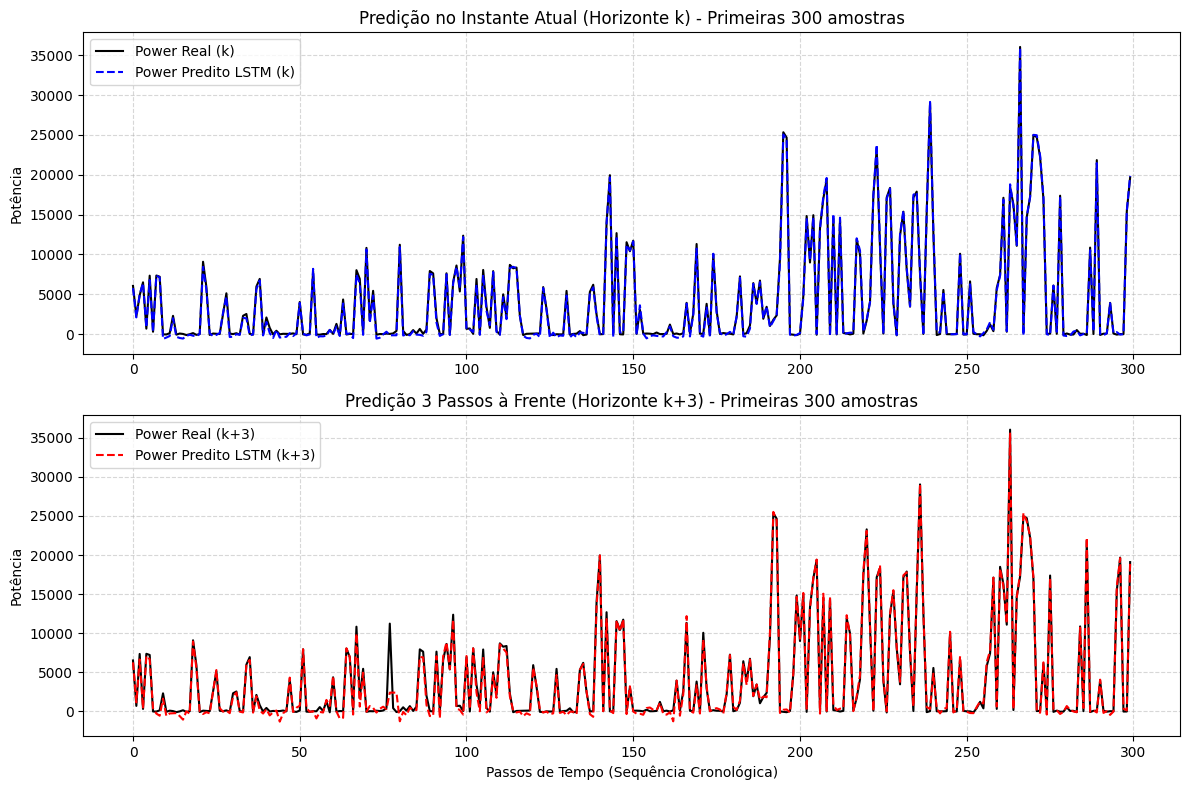

In [ ]:
# Criando a figura para comparação dos horizontes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Subplot 1: Predição no Instante Atual (k) - Geralmente mais precisa
ax1.plot(y_real_k[:300], label='Power Real (k)', color='black', linewidth=1.5)
ax1.plot(y_pred_k[:300], label='Power Predito LSTM (k)', color='blue', linestyle='--', linewidth=1.5)
ax1.set_title('Predição no Instante Atual (Horizonte k) - Primeiras 300 amostras')
ax1.set_ylabel('Potência')
ax1.legend(frameon=True)
ax1.grid(True, linestyle='--', alpha=0.5)

# Subplot 2: Predição 3 Passos à Frente (k+3) - Onde o erro tende a acumular
ax1.set_xlabel('') # Remove o label superior
ax2.plot(y_real_k3[:300], label='Power Real (k+3)', color='black', linewidth=1.5)
ax2.plot(y_pred_k3[:300], label='Power Predito LSTM (k+3)', color='red', linestyle='--', linewidth=1.5)
ax2.set_title('Predição 3 Passos à Frente (Horizonte k+3) - Primeiras 300 amostras')
ax2.set_xlabel('Passos de Tempo (Sequência Cronológica)')
ax2.set_ylabel('Potência')
ax2.legend(frameon=True)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()